## 1. Mount Google Drive (source of the dataset only)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Imports

In [2]:
import os
import json
import time
import random
import shutil
import pickle
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from tqdm.auto import tqdm

## 3. Configuration

In [3]:
# ==========================
# Configuration
# ==========================

# Where the ORIGINAL dataset lives (Google Drive - slow for many small files)
DRIVE_DATASET_ROOT = "/content/drive/MyDrive/data/logmel_dataset"

# Where we copy the dataset to for fast local access (Colab's local SSD, /content is local disk)
LOCAL_DATASET_ROOT = "/content/local_data/logmel_dataset"

DRIVE_METADATA_PATH = os.path.join(DRIVE_DATASET_ROOT, "metadata.csv")
DRIVE_LABEL_MAP_PATH = os.path.join(DRIVE_DATASET_ROOT, "label_map.json")

BATCH_SIZE = 64
LEARNING_RATE = 1e-3
EPOCHS = 20
IMAGE_SIZE = 128
SEED = 42

# Early stopping (monitors validation loss)
EARLY_STOPPING_PATIENCE = 5
EARLY_STOPPING_MIN_DELTA = 1e-4

# LR scheduler (reduces LR when validation loss plateaus)
LR_SCHEDULER_PATIENCE = 2
LR_SCHEDULER_FACTOR = 0.5
LR_MIN = 1e-6

# Number of parallel workers used to copy files from Drive -> local SSD
# and by the DataLoader once data is local. Colab gives ~2 CPU cores on the free tier.
COPY_WORKERS = 32
DATALOADER_WORKERS = 2

# All training artifacts are written here first (fast local disk),
# then copied back to Drive so they survive when the runtime resets.
LOCAL_OUTPUT_DIR = "/content/local_outputs"
DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/data/logmel_dataset_outputs"

os.makedirs(LOCAL_OUTPUT_DIR, exist_ok=True)
os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", DEVICE)
if DEVICE.type == "cuda":
    print(torch.cuda.get_device_name(0))

Device : cuda
Tesla T4


In [4]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## 4. Copy the dataset to local SSD

Reading thousands of small `.npy` files straight off a Drive mount is slow because every read pays
network/FUSE latency. Copying the whole dataset to `/content` (Colab's local SSD) once, then reading
from there for every epoch, removes that bottleneck entirely.

The copy uses a thread pool because the wait is I/O latency, not CPU — parallel requests to Drive
finish far faster than one file at a time. Re-running this cell is cheap: any file that's already
present locally (and the right size) is skipped.

In [5]:
def copy_dataset_to_local(filepaths, drive_root, local_root, max_workers=32):
    """
    Copies every path in `filepaths` (relative to drive_root) into local_root,
    preserving the folder structure. Returns the list of new local paths in the
    same order as the input.
    """
    os.makedirs(local_root, exist_ok=True)

    def _copy_one(src_path):
        rel_path = os.path.relpath(src_path, drive_root)
        dst_path = os.path.join(local_root, rel_path)
        os.makedirs(os.path.dirname(dst_path), exist_ok=True)

        if os.path.exists(dst_path) and os.path.getsize(dst_path) == os.path.getsize(src_path):
            return dst_path  # already copied in a previous run

        shutil.copy2(src_path, dst_path)
        return dst_path

    local_paths = [None] * len(filepaths)

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(_copy_one, p): i for i, p in enumerate(filepaths)}
        for future in tqdm(as_completed(futures), total=len(futures), desc="Copying to local SSD"):
            i = futures[future]
            local_paths[i] = future.result()

    return local_paths

In [6]:
raw_metadata = pd.read_csv(DRIVE_METADATA_PATH)
print("Shape :", raw_metadata.shape)

# Drop any previously identified corrupted files before copying (saves time + avoids bad data)
KNOWN_BAD_FILES = [
    "/content/drive/MyDrive/data/logmel_dataset/tf_ljspeech_FASTSPEECH_MB-MELGAN/3a8a5cf359a9746cd6a72bc98df5b953.npy",
]
raw_metadata = raw_metadata[~raw_metadata["filepath"].isin(KNOWN_BAD_FILES)].reset_index(drop=True)
print("Shape after dropping known-bad files :", raw_metadata.shape)

local_paths = copy_dataset_to_local(
    raw_metadata["filepath"].tolist(),
    drive_root=DRIVE_DATASET_ROOT,
    local_root=LOCAL_DATASET_ROOT,
    max_workers=COPY_WORKERS,
)

metadata = raw_metadata.copy()
metadata["filepath"] = local_paths

if os.path.exists(DRIVE_LABEL_MAP_PATH):
    shutil.copy2(DRIVE_LABEL_MAP_PATH, os.path.join(LOCAL_DATASET_ROOT, "label_map.json"))

# Persist the local-path metadata so it can be reused without re-scanning Drive
metadata.to_csv(os.path.join(LOCAL_DATASET_ROOT, "metadata_local.csv"), index=False)

print("Training will now read spectrograms from:", LOCAL_DATASET_ROOT)

Shape : (34861, 2)
Shape after dropping known-bad files : (34861, 2)


Copying to local SSD:   0%|          | 0/34861 [00:00<?, ?it/s]

Training will now read spectrograms from: /content/local_data/logmel_dataset


## 5. Explore the data

In [7]:
print("\nColumns:")
print(metadata.columns)

print("\nMissing Values:")
print(metadata.isnull().sum())

print("\nNumber of Classes:")
print(metadata["label"].nunique())

print("\nSamples per Class:")
print(metadata["label"].value_counts())


Columns:
Index(['filepath', 'label'], dtype='object')

Missing Values:
filepath    0
label       0
dtype: int64

Number of Classes:
25

Samples per Class:
label
8     1406
0     1394
1     1394
3     1394
2     1394
4     1394
5     1394
6     1394
7     1394
9     1394
10    1394
11    1394
12    1394
13    1394
14    1394
15    1394
17    1394
21    1394
18    1394
19    1394
20    1394
23    1394
22    1394
24    1394
16    1393
Name: count, dtype: int64


## 6. Encode labels

In [8]:
label_encoder = LabelEncoder()
metadata["label"] = label_encoder.fit_transform(metadata["label"])

NUM_CLASSES = len(label_encoder.classes_)
print("Number of Classes :", NUM_CLASSES)

metadata.head()

Number of Classes : 25


,filepath,label
0,/content/local_data/logmel_dataset/cv4_fastspe...,0
1,/content/local_data/logmel_dataset/cv4_fastspe...,0
2,/content/local_data/logmel_dataset/cv4_fastspe...,0
3,/content/local_data/logmel_dataset/cv4_fastspe...,0
4,/content/local_data/logmel_dataset/cv4_fastspe...,0


In [9]:
label_encoder_path = os.path.join(LOCAL_OUTPUT_DIR, "label_encoder.pkl")

with open(label_encoder_path, "wb") as f:
    pickle.dump(label_encoder, f)

print("Label encoder saved to:", label_encoder_path)

Label encoder saved to: /content/local_outputs/label_encoder.pkl


## 7. Train / validation split

In [10]:
train_df, val_df = train_test_split(
    metadata,
    test_size=0.2,
    random_state=SEED,
    stratify=metadata["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Training Samples :", len(train_df))
print("Validation Samples :", len(val_df))

Training Samples : 27888
Validation Samples : 6973


## 8. Dataset & DataLoaders

In [11]:
class SpeechDataset(Dataset):

    def __init__(self, dataframe):
        self.data = dataframe

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        path = self.data.iloc[idx]["filepath"]
        label = self.data.iloc[idx]["label"]

        try:
            spec = np.load(path)
        except Exception as e:
            print(f"Error loading file {path}: {e}")
            raise e

        # (128,128) -> (1,128,128)
        spec = np.expand_dims(spec, axis=0)
        spec = torch.tensor(spec, dtype=torch.float32)
        label = torch.tensor(label, dtype=torch.long)

        return spec, label

In [12]:
train_dataset = SpeechDataset(train_df)
val_dataset = SpeechDataset(val_df)

print("Training Samples :", len(train_dataset))
print("Validation Samples :", len(val_dataset))

Training Samples : 27888
Validation Samples : 6973


In [13]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=DATALOADER_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=(DATALOADER_WORKERS > 0),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=DATALOADER_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=(DATALOADER_WORKERS > 0),
)

In [14]:
images, labels = next(iter(train_loader))

print("Images Shape :", images.shape)
print("Labels Shape :", labels.shape)
print(images.dtype)
print(labels.dtype)

Images Shape : torch.Size([64, 1, 128, 128])
Labels Shape : torch.Size([64])
torch.float32
torch.int64


## 9. Model

In [15]:
class CNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        # -------- Feature Extractor --------
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # -------- Classifier --------
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 32 * 32, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        # Block 1
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        # Block 2
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        # Flatten + FC
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)

        # Output logits
        x = self.fc2(x)
        return x

In [16]:
model = CNN(num_classes=NUM_CLASSES).to(DEVICE)
print(model)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=65536, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=25, bias=True)
)


In [17]:
images, labels = next(iter(train_loader))
images = images.to(DEVICE)

outputs = model(images)

print("Input Shape :", images.shape)
print("Output Shape:", outputs.shape)

Input Shape : torch.Size([64, 1, 128, 128])
Output Shape: torch.Size([64, 25])


## 10. Loss, optimizer, LR scheduler, early stopping

In [18]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

# Reduces the LR when validation loss stops improving
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=LR_SCHEDULER_FACTOR,
    patience=LR_SCHEDULER_PATIENCE,
    min_lr=LR_MIN,
)

In [19]:
class EarlyStopping:
    """Stops training when a monitored value has stopped improving for `patience` epochs."""

    def __init__(self, patience=5, min_delta=1e-4, mode="min"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.best_score = None
        self.counter = 0
        self.should_stop = False

    def step(self, value):
        if self.best_score is None:
            self.best_score = value
            return True

        improved = (
            (self.mode == "min" and value < self.best_score - self.min_delta)
            or (self.mode == "max" and value > self.best_score + self.min_delta)
        )

        if improved:
            self.best_score = value
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

        return improved

In [20]:
def calculate_accuracy(outputs, labels):
    predictions = torch.argmax(outputs, dim=1)
    correct = (predictions == labels).sum().item()
    return correct / labels.size(0)

## 11. Train / validate loops

In [21]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    running_accuracy = 0.0

    progress_bar = tqdm(dataloader)

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_accuracy += calculate_accuracy(outputs, labels)

        progress_bar.set_description(f"Loss: {loss.item():.4f}")

    epoch_loss = running_loss / len(dataloader)
    epoch_accuracy = running_accuracy / len(dataloader)
    return epoch_loss, epoch_accuracy

In [22]:
def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_accuracy = 0.0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            running_accuracy += calculate_accuracy(outputs, labels)

    epoch_loss = running_loss / len(dataloader)
    epoch_accuracy = running_accuracy / len(dataloader)
    return epoch_loss, epoch_accuracy

## 12. Training loop (with LR scheduling + early stopping)

In [23]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}

early_stopping = EarlyStopping(
    patience=EARLY_STOPPING_PATIENCE,
    min_delta=EARLY_STOPPING_MIN_DELTA,
    mode="min",
)

best_val_acc = 0.0
best_model_path = os.path.join(LOCAL_OUTPUT_DIR, "best_model.pth")

for epoch in range(EPOCHS):
    start = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc = validate_one_epoch(model, val_loader, criterion, DEVICE)

    current_lr = optimizer.param_groups[0]["lr"]
    scheduler.step(val_loss)

    elapsed = time.time() - start

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
        f"LR: {current_lr:.2e} | Time: {elapsed:.1f}s"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print("Best model saved (by validation accuracy)")

    early_stopping.step(val_loss)
    if early_stopping.should_stop:
        print(f"Early stopping triggered at epoch {epoch+1} "
              f"(val_loss hasn't improved for {EARLY_STOPPING_PATIENCE} epochs)")
        break

with open(os.path.join(LOCAL_OUTPUT_DIR, "history.json"), "w") as f:
    json.dump(history, f, indent=2)

print("Best validation accuracy:", best_val_acc)

  0%|          | 0/436 [00:00<?, ?it/s]

Epoch [1/20] | Train Loss: 1.1471 | Train Acc: 0.6379 | Val Loss: 0.4189 | Val Acc: 0.8603 | LR: 1.00e-03 | Time: 37.9s
Best model saved (by validation accuracy)


  0%|          | 0/436 [00:00<?, ?it/s]

Epoch [2/20] | Train Loss: 0.2108 | Train Acc: 0.9240 | Val Loss: 0.2526 | Val Acc: 0.9078 | LR: 1.00e-03 | Time: 26.0s
Best model saved (by validation accuracy)


  0%|          | 0/436 [00:00<?, ?it/s]

...

Epoch [8/20] | Train Loss: 0.0223 | Train Acc: 0.9930 | Val Loss: 0.1745 | Val Acc: 0.9512 | LR: 1.00e-03 | Time: 19.2s


  0%|          | 0/436 [00:00<?, ?it/s]

Epoch [9/20] | Train Loss: 0.0035 | Train Acc: 0.9994 | Val Loss: 0.1508 | Val Acc: 0.9614 | LR: 5.00e-04 | Time: 20.4s
Best model saved (by validation accuracy)


  0%|          | 0/436 [00:00<?, ?it/s]

Epoch [10/20] | Train Loss: 0.0006 | Train Acc: 1.0000 | Val Loss: 0.1522 | Val Acc: 0.9600 | LR: 5.00e-04 | Time: 19.3s
Early stopping triggered at epoch 10 (val_loss hasn't improved for 5 epochs)
Best validation accuracy: 0.9613898706572418


## 13. Training curves

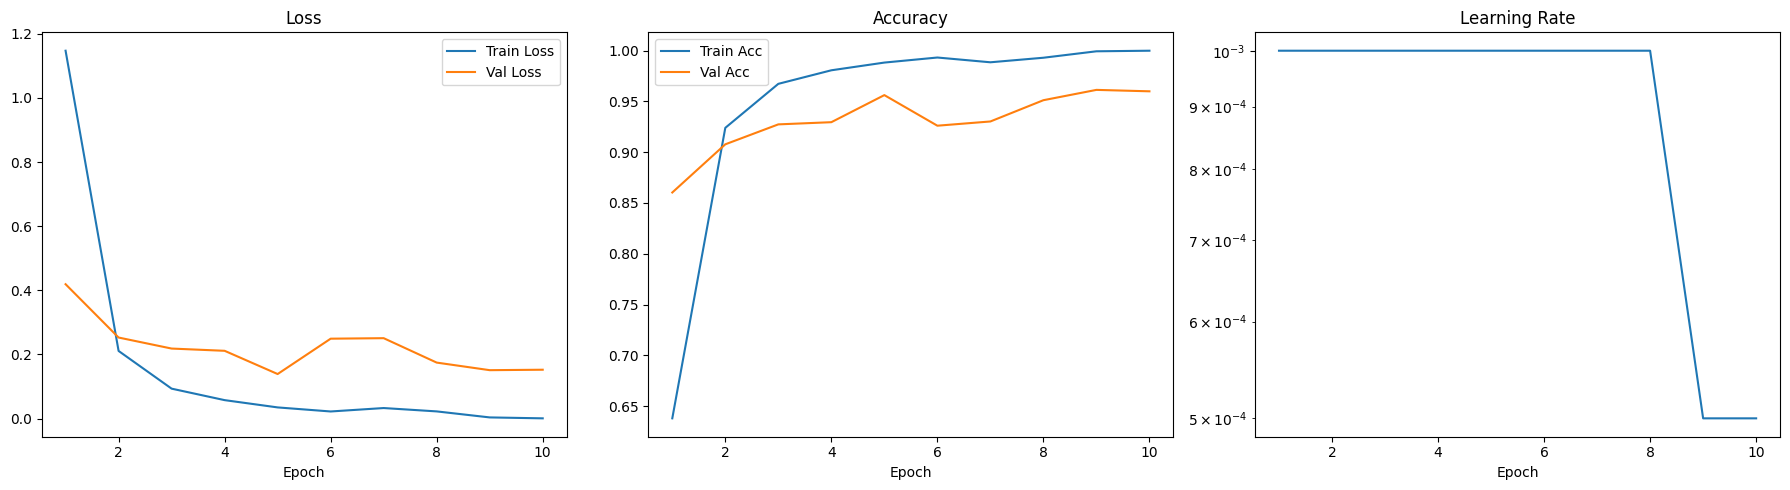

In [24]:
def plot_training_curves(history, save_path=None):
    epochs_range = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs_range, history["val_loss"], label="Val Loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(epochs_range, history["train_acc"], label="Train Acc")
    axes[1].plot(epochs_range, history["val_acc"], label="Val Acc")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    axes[2].plot(epochs_range, history["lr"])
    axes[2].set_title("Learning Rate")
    axes[2].set_xlabel("Epoch")
    axes[2].set_yscale("log")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

plot_training_curves(history, save_path=os.path.join(LOCAL_OUTPUT_DIR, "training_curves.png"))

## 14. Evaluation metrics (classification report + confusion matrix)

In [25]:
def evaluate_model(model, dataloader, device, class_names=None):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    report = classification_report(
        all_labels, all_preds, target_names=class_names, digits=4, zero_division=0
    )
    cm = confusion_matrix(all_labels, all_preds)
    return report, cm, all_preds, all_labels

In [26]:
# Reload the best checkpoint before final evaluation
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.to(DEVICE)

class_names = [str(c) for c in label_encoder.classes_]
report, cm, y_pred, y_true = evaluate_model(model, val_loader, DEVICE, class_names=class_names)

print(report)

with open(os.path.join(LOCAL_OUTPUT_DIR, "classification_report.txt"), "w") as f:
    f.write(report)

              precision    recall  f1-score   support

           0     1.0000    0.9964    0.9982       278
           1     1.0000    1.0000    1.0000       279
           2     1.0000    0.9964    0.9982       279
           3     0.8984    0.9821    0.9384       279
           4     0.9928    0.9892    0.9910       279
           5     0.9816    0.9570    0.9691       279
           6     0.9782    0.9642    0.9711       279
           7     0.9660    0.9176    0.9412       279
           8     0.9719    0.9858    0.9788       281
           9     0.9776    0.9391    0.9580       279
          10     1.0000    1.0000    1.0000       278
          11     0.9823    0.9964    0.9893       279
          12     1.0000    0.9928    0.9964       279
          13     0.9680    0.9749    0.9714       279
          14     0.9202    0.8674    0.8930       279
          15     0.9010    0.9462    0.9231       279
          16     0.9782    0.9676    0.9729       278
          17     0.8889    

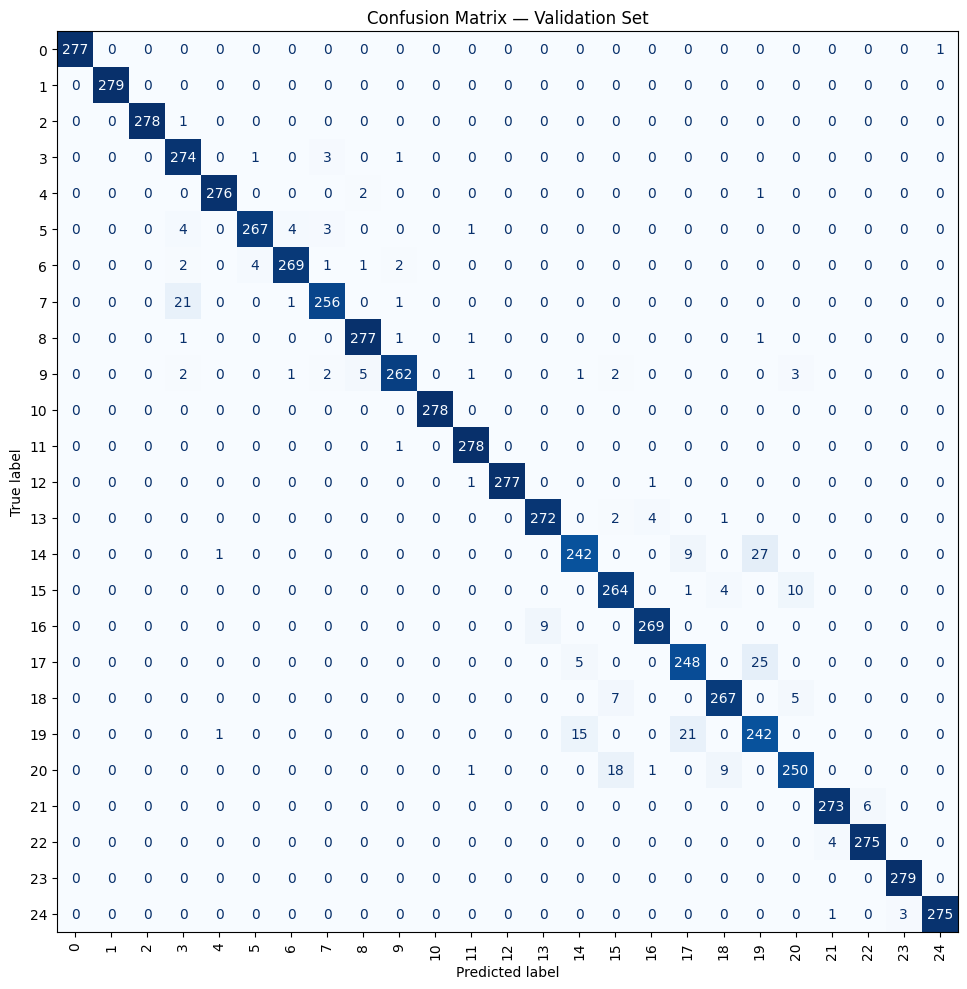

In [27]:
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False, cmap="Blues")
plt.title("Confusion Matrix — Validation Set")
plt.tight_layout()
plt.savefig(os.path.join(LOCAL_OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

## 15. Save the final model and back everything up to Drive

In [28]:
final_model_path = os.path.join(LOCAL_OUTPUT_DIR, "cnn_speaker_classifier.pth")
torch.save(model.state_dict(), final_model_path)
print("Final model saved to:", final_model_path)

Final model saved to: /content/local_outputs/cnn_speaker_classifier.pth


In [29]:
# /content is wiped when the Colab runtime resets, so copy every artifact back to Drive.
artifacts_to_backup = [
    "best_model.pth",
    "cnn_speaker_classifier.pth",
    "history.json",
    "training_curves.png",
    "classification_report.txt",
    "confusion_matrix.png",
    "label_encoder.pkl",
]

for name in artifacts_to_backup:
    src = os.path.join(LOCAL_OUTPUT_DIR, name)
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(DRIVE_OUTPUT_DIR, name))
        print("Backed up:", name)
    else:
        print("Skipped (not found):", name)

print("\nAll artifacts backed up to:", DRIVE_OUTPUT_DIR)

Backed up: best_model.pth
Backed up: cnn_speaker_classifier.pth
Backed up: history.json
Backed up: training_curves.png
Backed up: classification_report.txt
Backed up: confusion_matrix.png
Backed up: label_encoder.pkl

All artifacts backed up to: /content/drive/MyDrive/data/logmel_dataset_outputs


## 16. Inference



```bash
python inference.py \
    --model /content/drive/MyDrive/data/logmel_dataset_outputs/best_model.pth \
    --label-encoder /content/drive/MyDrive/data/logmel_dataset_outputs/label_encoder.pkl \
    --input /path/to/a_spectrogram.npy
```

